In [1]:
import pandas as pd
import scipy.stats
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/card transactions_2025.csv')

In [3]:
df['Merch zip'] = df['Merch zip'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
df['Recnum'] = df['Recnum'].astype(str)
df['Cardnum'] = df['Cardnum'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')

### Exclusion

In [ ]:
df = df[df["Amount"] < 3000000]

In [5]:
df = df[df['Transtype'] == 'P']

### Outlier

#### Dealing with Spike in $3.62

Recall this graph from 1_data_exploration.ipynb.

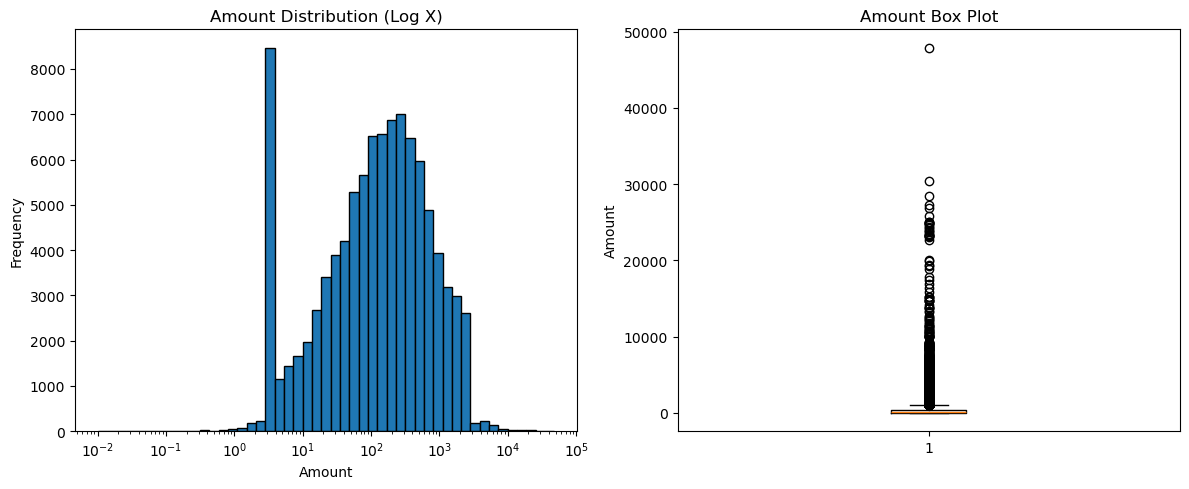

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=np.logspace(np.log10(df['Amount'].min()), np.log10(df['Amount'].max()), 50), edgecolor='black')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.xscale('log')
# plt.yscale('log')
plt.title('Amount Distribution (Log X)')

plt.subplot(1, 2, 2)
plt.boxplot(df['Amount'])
plt.ylabel('Amount')
# plt.yscale('log')
plt.title('Amount Box Plot')

plt.tight_layout()
plt.show()

In [7]:
df['Amount'].value_counts().head(5)

Amount
3.62    4283
3.67    1620
3.74     913
3.80     827
4.37     378
Name: count, dtype: int64

In [8]:
# Check fraud distribution for the most common amounts
for amount in df['Amount'].value_counts().head(5).index:
    fraud_count = df[df['Amount'] == amount]['Fraud'].sum()
    total_count = df[df['Amount'] == amount].shape[0]
    print(f"Amount ${amount}: {fraud_count} frauds out of {total_count} transactions ({fraud_count/total_count*100:.2f}%)")

Amount $3.62: 0 frauds out of 4283 transactions (0.00%)
Amount $3.67: 0 frauds out of 1620 transactions (0.00%)
Amount $3.74: 0 frauds out of 913 transactions (0.00%)
Amount $3.8: 0 frauds out of 827 transactions (0.00%)
Amount $4.37: 0 frauds out of 378 transactions (0.00%)


We will keep the anomaly in the dataset, but will flag them.

In [9]:
# Flag FedEx transactions in the $3.62-$3.80 range
is_fedex = df['Merch description'].str[:5] == "FEDEX"
is_suspicious_amount = (df['Amount'] >= 3.62) & (df['Amount'] <= 3.80)
df['amount_okay'] = ~(is_fedex & is_suspicious_amount)

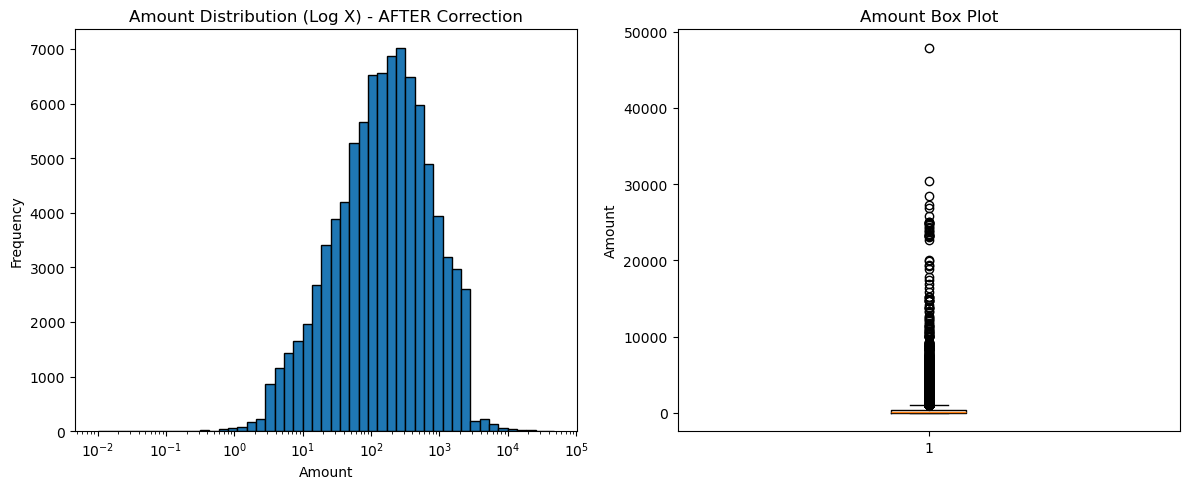

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df[df['amount_okay'] == 1]['Amount'], bins=np.logspace(np.log10(df['Amount'].min()), np.log10(df['Amount'].max()), 50), edgecolor='black')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.xscale('log')
# plt.yscale('log')
plt.title('Amount Distribution (Log X) - AFTER Correction')

plt.subplot(1, 2, 2)
plt.boxplot(df['Amount'])
plt.ylabel('Amount')
# plt.yscale('log')
plt.title('Amount Box Plot')

plt.tight_layout()
plt.show()

### Imputation

In [11]:
df['Merchnum'] = df['Merchnum'].replace({'0':np.nan})

In [12]:
df.isna().sum()

Recnum                  0
Cardnum                 0
Date                    0
Merchnum             3306
Merch description       0
Merch state          1037
Merch zip            4373
Transtype               0
Amount                  0
Fraud                   0
amount_okay             0
dtype: int64

#### Merchnum

Fill in missing Merchnum values based on Merch description.

In [13]:
valid_rows = df[df['Merch description'].notnull() & df['Merchnum'].notnull()]

# dictionary: first occurrence of each merchant description
merchdes_to_merchnum = {}
for index, row in valid_rows.iterrows():
    merchdes = row['Merch description']
    if merchdes not in merchdes_to_merchnum:
        merchdes_to_merchnum[merchdes] = row['Merchnum']

df['Merchnum'] = df['Merchnum'].fillna(df['Merch description'].map(merchdes_to_merchnum))

Assign 'unknown' for adjustment transactions.

In [14]:
adjustment_types = ['RETAIL CREDIT ADJUSTMENT', 'RETAIL DEBIT ADJUSTMENT']
df['Merchnum'] = df['Merchnum'].mask(df['Merch description'].isin(adjustment_types), 'unknown')

Create new Merchnums using the description field

In [15]:
null_count = df['Merchnum'].isnull().sum()
unique_descriptions = df.loc[df['Merchnum'].isna(), 'Merch description'].nunique()

print(f"Remaining null Merchnum values: {null_count}")
print(f"Unique merchant descriptions with null Merchnum: {unique_descriptions}")

Remaining null Merchnum values: 1437
Unique merchant descriptions with null Merchnum: 515


In [16]:
# Assign sequential numbers starting from max existing Merchnum + 1
max_merchnum = pd.to_numeric(df['Merchnum'], errors='coerce').max()

# Map each unique merchant description to a new number
null_descriptions = df.loc[df['Merchnum'].isna(), 'Merch description'].unique()
merchnum_mapping = {desc: str(int(max_merchnum + i + 1)) for i, desc in enumerate(null_descriptions)}

# Fill
df['Merchnum'] = df['Merchnum'].fillna(df['Merch description'].map(merchnum_mapping))

#### Merch state

In [17]:
# Create mapping of zip code to state from known valid pairs
valid_rows = df[df['Merch zip'].notnull() & df['Merch state'].notnull()]
zip_to_state = {}
for index, row in valid_rows.iterrows():
    zip_code = row['Merch zip']
    if zip_code not in zip_to_state:
        zip_to_state[zip_code] = row['Merch state']

# Manual mappings for specific zip codes (already in string form without decimals)
manual_mappings = {
    '926': 'PR', '929': 'PR', '934': 'PR', '902': 'PR', '738': 'PR',
    '90805': 'CA', '76302': 'TX', '914': 'PR', '95461': 'CA', '680': 'PR',
    '623': 'PR', '726': 'PR', '936': 'PR', '12108': 'NY', '791': 'PR',
    '907': 'PR', '922': 'PR', '920': 'PR', '801': 'VI', '31040': 'GA',
    '41160': 'KY', '681': 'PR'
}

# Update mapping with manual entries
zip_to_state.update(manual_mappings)

# Fill missing state values using the zip code mapping
df['Merch state'] = df['Merch state'].fillna(df['Merch zip'].map(zip_to_state))

In [18]:
# Create mapping of merchant number to state (exclude 'unknown')
valid_merchnum = df[(df['Merchnum'].notnull()) & (df['Merch state'].notnull()) & (df['Merchnum'] != 'unknown')]
merchnum_to_state = {}
for index, row in valid_merchnum.iterrows():
    merchnum = row['Merchnum']
    if merchnum not in merchnum_to_state:
        merchnum_to_state[merchnum] = row['Merch state']

# Create mapping of merchant description to state
valid_merchdes = df[df['Merch description'].notnull() & df['Merch state'].notnull()]
merchdes_to_state = {}
for index, row in valid_merchdes.iterrows():
    merchdes = row['Merch description']
    if merchdes not in merchdes_to_state:
        merchdes_to_state[merchdes] = row['Merch state']

# Fill
df['Merch state'] = df['Merch state'].fillna(df['Merchnum'].map(merchnum_to_state))
df['Merch state'] = df['Merch state'].fillna(df['Merch description'].map(merchdes_to_state))

In [19]:
adjustment_types = ['RETAIL CREDIT ADJUSTMENT', 'RETAIL DEBIT ADJUSTMENT']
df['Merch state'] = df['Merch state'].mask(df['Merch description'].isin(adjustment_types), 'unknown')

In [20]:
# Mark non-US states as 'foreign'
us_states = ["AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DC", "DE", "FL", "GA", 
             "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD", 
             "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ", 
             "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", 
             "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY", 
             'VI', 'PR', 'unknown']

df['Merch state'] = df['Merch state'].apply(lambda x: 'foreign' if pd.notna(x) and x not in us_states else x)

In [21]:
df['Merch state'] = df['Merch state'].fillna('unknown')

#### Merch zip

In [22]:
# Create mappings for zip code imputation (exclude 'unknown' Merchnum)
valid_merchnum = df[(df['Merchnum'].notnull()) & (df['Merch zip'].notnull()) & (df['Merchnum'] != 'unknown')]
merchnum_to_zip = {}
for index, row in valid_merchnum.iterrows():
    merchnum = row['Merchnum']
    if merchnum not in merchnum_to_zip:
        merchnum_to_zip[merchnum] = row['Merch zip']

valid_merchdes = df[df['Merch description'].notnull() & df['Merch zip'].notnull()]
merchdes_to_zip = {}
for index, row in valid_merchdes.iterrows():
    merchdes = row['Merch description']
    if merchdes not in merchdes_to_zip:
        merchdes_to_zip[merchdes] = row['Merch zip']

# Fill missing zip codes
df['Merch zip'] = df['Merch zip'].fillna(df['Merchnum'].map(merchnum_to_zip))
df['Merch zip'] = df['Merch zip'].fillna(df['Merch description'].map(merchdes_to_zip))

In [23]:
# Assign 'unknown' for adjustment transactions
adjustment_types = ['RETAIL CREDIT ADJUSTMENT', 'RETAIL DEBIT ADJUSTMENT']
df['Merch zip'] = df['Merch zip'].mask(df['Merch description'].isin(adjustment_types), 'unknown')

In [24]:
# Map most populous zip code for each state
state_to_zip = {
    'AL': '35205', 'AK': '99501', 'AZ': '85281', 'AR': '72701', 'CA': '90026', 'CO': '80219',
    'CT': '06511', 'DE': '19801', 'FL': '33139', 'GA': '30303', 'HI': '96744', 'ID': '83702',
    'IL': '60647', 'IN': '46201', 'IA': '52404', 'KS': '66102', 'KY': '40203', 'LA': '70119',
    'ME': '04101', 'MD': '21224', 'MA': '02118', 'MI': '48201', 'MN': '55406', 'MS': '38801',
    'MO': '63118', 'MT': '59101', 'NE': '68104', 'NV': '89101', 'NH': '03103', 'NJ': '07030',
    'NM': '87102', 'NY': '11226', 'NC': '28202', 'ND': '58102', 'OH': '44113', 'OK': '74120',
    'OR': '97214', 'PA': '19107', 'RI': '02903', 'SC': '29203', 'SD': '57103', 'TN': '37203',
    'TX': '77002', 'UT': '84101', 'VT': '05401', 'VA': '22201', 'WA': '98122', 'WV': '25301',
    'WI': '53204', 'WY': '82001'
}

df['Merch zip'] = df['Merch zip'].fillna(df['Merch state'].map(state_to_zip))

In [25]:
df['Merch zip'] = df['Merch zip'].fillna('unknown')

In [26]:
df.isna().sum()

Recnum               0
Cardnum              0
Date                 0
Merchnum             0
Merch description    0
Merch state          0
Merch zip            0
Transtype            0
Amount               0
Fraud                0
amount_okay          0
dtype: int64

### Data Formatting

In [27]:
# Add leading zeros to zip codes (for numeric zips only)
def leading_0(x):
    x = str(x)
    # Only pad numeric values that are less than 5 characters
    if x.isdigit() and len(x) < 5:
        return '0' * (5 - len(x)) + x
    else:
        return x

df['Merch zip'] = df['Merch zip'].apply(leading_0)

In [28]:
# Remove whitespaces from Merch description
df['Merch description'] = df['Merch description'].str.replace(r'\s', '', regex=True)

### Output Data

In [29]:
df.to_csv('data/cleaned_card_transactions_2025.csv', index=False)